[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/josterri/predicting-the-next-words-notebooks/blob/main/ch05-concepts_workbook.ipynb)

# Two numbers after `the cat`

A recurrent network keeps two numbers and reads `the`, then `cat`. After
`cat`, do the two numbers still hold anything of `the`? And how much of a
learning signal sent back from a later word reaches a word many steps
earlier?

In [1]:
#@title Setup: run this cell first
import math

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator
from IPython.display import Markdown, display

# The book's two-unit recurrent network: the weights on the old state and on the new word.
W_HH = np.array([[0.5, 0.1], [0.2, 0.3]])
W_XH = np.array([[0.4, 0.2], [0.1, 0.3]])
plt.rcParams.update({"xtick.labelsize": 8, "ytick.labelsize": 8})


class Refused(Exception):  # a setting a cell refuses: Colab prints the one sentence, without the stack
    _render_traceback_ = lambda self: [str(self)]  # noqa: E731


def fmt(v):  # a vector as (0.380, 0.385)
    return "(" + ", ".join(f"{x:.3f}" for x in v) + ")"


def number(name, x, lo, hi):  # a setting typed in a cell: one number from lo to hi
    if type(x) not in (int, float) or not lo <= x <= hi:
        raise Refused(f"{name} is {x!r}: {name} takes a number from {lo:g} to {hi:g}.")
    return float(x)


def sigma(z):  # the logistic function: a gate's value from its bias
    return 1 / (1 + math.exp(-z))


def bars(title, labels, values, xlabel, focus):  # one chart of labelled bars, the focus in red, negative values left of 0
    fig, ax = plt.subplots(figsize=(6, 0.45 * len(values) + 1.2), layout="constrained")
    b = ax.barh(range(len(values)), values, tick_label=labels, color=["C3" if x == focus else "C0" for x in labels])
    ax.bar_label(b, fmt="%.3f", padding=2, fontsize=8)
    lo, hi = min(0, *values), max(0, *values)
    pad = 0.35 * ((hi - lo) or 1)
    ax.set(title=title, xlabel=xlabel, xlim=(lo - pad if lo < 0 else 0, hi + pad if hi > 0 else pad), ylim=(len(values) - 0.5, -0.5))
    ax.axvline(0, color="0.5", lw=0.8)
    plt.show()


# Step 1: two steps, h_t = tanh(W_HH h_(t-1) + W_XH x_t), from the state 0; MEMORY False drops the
# old state from step two.
def states(x1, x2, memory=True):
    xs = []
    for name, x in (("X1", x1), ("X2", x2)):
        a = np.asarray(x, dtype=float) if isinstance(x, (list, tuple, np.ndarray)) else None
        if a is None or a.shape != (2,) or not np.isfinite(a).all() or abs(a).max() > 10:
            raise Refused(f"{name} is {x!r}: {name} takes a list of two numbers from -10 to 10.")
        xs.append(a)
    if not isinstance(memory, bool):
        raise Refused(f"MEMORY is {memory!r}: MEMORY takes True or False.")
    h1 = np.tanh(W_XH @ xs[0])
    carried = W_HH @ h1 if memory else np.zeros(2)
    return h1, carried, W_XH @ xs[1], np.tanh(carried + W_XH @ xs[1])


def fold(x1, x2, memory):
    h1, carried, new, h2 = states(x1, x2, memory)
    print(f"step 1: state {fmt(h1)}")
    print(f"step 2: old state {fmt(carried)} + new word {fmt(new)} = {fmt(carried + new)}, state {fmt(h2)}")
    fig, ax = plt.subplots(figsize=(6, 2.4), layout="constrained")
    for k, (h, name) in enumerate(((h1, "after step 1"), (h2, "after step 2"))):
        b = ax.bar(np.arange(2) + 0.38 * k - 0.19, h, 0.36, label=name, color=("C0", "C3")[k])
        ax.bar_label(b, fmt="%.3f", fontsize=8)
    ax.set(xticks=[0, 1], xticklabels=["first number", "second number"], ylim=(min(0, *h1, *h2) - 0.15, 1),
           title="the two numbers of the state" + ("" if memory else ", old state dropped"))
    ax.legend(fontsize=8)
    plt.show()


# Step 2: a signal sent back k steps is multiplied by the factor once per step.
def signal(factors, steps):
    if not isinstance(factors, dict) or not factors or not all(type(f) in (int, float) and 0 < f < 2 for f in factors.values()):
        raise Refused(f"FACTORS is {factors!r}: FACTORS takes names with a number above 0 and below 2 each.")
    if type(steps) is not int or not 1 <= steps <= 200:
        raise Refused(f"STEPS is {steps!r}: STEPS takes a whole number from 1 to 200.")
    k = np.arange(steps + 1)
    fig, ax = plt.subplots(figsize=(6, 2.8), layout="constrained")
    for name, f in factors.items():
        print(f"{name}: {f:.3f} per step, {f ** steps:.2g} left after {steps} steps")
        ax.plot(k, float(f) ** k, label=f"{name}: {f ** steps:.2g}")
    ax.set(yscale="log", xlabel="steps back", ylabel="signal left", title=f"the signal left after each step, {steps} steps")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.legend(fontsize=8)
    plt.show()


# Step 3: one cell-state step keeps F of the old value and writes I of the candidate; the hidden
# state shows O × tanh of the new value.
def cell(c_old, f, i, cand, o):
    c_old, cand = number("C_OLD", c_old, -10, 10), number("CAND", cand, -1, 1)
    f, i, o = number("F", f, 0, 1), number("I", i, 0, 1), number("O", o, 0, 1)
    new = f * c_old + i * cand
    return f * c_old + 0.0, i * cand + 0.0, new, o * math.tanh(new)  # + 0.0 prints -0.0 as 0.000


def cell_step(c_old, f, i, cand, o):
    kept, written, new, shown = cell(c_old, f, i, cand, o)
    print(f"kept {f:g} × {c_old:g} = {kept:.3f}; written {i:g} × {cand:g} = {written:.3f}; new value {new:.3f}")
    print(f"the hidden state shows {o:g} × tanh({new:.3f}) = {shown:.3f}")
    bars("one cell-state step", ["old value", "kept", "written", "new value", "shown"],
         [c_old, kept, written, new, shown], "value", "new value")


# Appendix: one GRU step keeps 1 − Z of the old value and writes Z of the candidate.
def gru_step(h_old, z, cand):
    h_old, z, cand = number("H_OLD", h_old, -1, 1), number("Z", z, 0, 1), number("CAND", cand, -1, 1)
    new = (1 - z) * h_old + z * cand
    print(f"kept {1 - z:.2f} × {h_old:g} = {(1 - z) * h_old + 0.0:.3f}; written {z:g} × {cand:g} = {z * cand + 0.0:.3f}; "
          f"new value {new:.3f}")
    bars("one GRU step", ["old value", "kept", "written", "new value"], [h_old, (1 - z) * h_old, z * cand, new], "value", "new value")


display(Markdown("The network's weights: `W_HH` " + fmt(W_HH[0]) + " and " + fmt(W_HH[1])
                 + " on the old state, `W_XH` " + fmt(W_XH[0]) + " and " + fmt(W_XH[1]) + " on the new word."))

The network's weights: `W_HH` (0.500, 0.100) and (0.200, 0.300) on the old state, `W_XH` (0.400, 0.200) and (0.100, 0.300) on the new word.

## 1. Two steps by hand

Each step adds the old state, multiplied by `W_HH`, to the new word,
multiplied by `W_XH`, and tanh maps each entry into the range from -1 to 1.
The word `the` is `[1, 0]` and `cat` is `[0, 1]`. Run the cell: what is the
state after `cat`? Then set `MEMORY` to `False`, which drops the old state
from step two, and run it again. Then swap `X1` and `X2`.

step 1: state (0.380, 0.100)
step 2: old state (0.200, 0.106) + new word (0.200, 0.300) = (0.400, 0.406), state (0.380, 0.385)


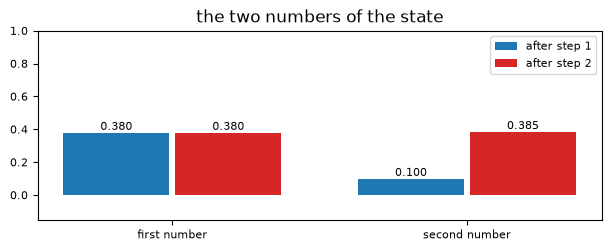

In [2]:
X1 = [1, 0]  # the
X2 = [0, 1]  # cat
MEMORY = True
fold(X1, X2, MEMORY)

### Solution

In [3]:
with_memory, without, swapped = states([1, 0], [0, 1])[3], states([1, 0], [0, 1], False)[3], states([0, 1], [1, 0])[3]
display(Markdown(f"With the old state `the` reaches step two and the state is {fmt(with_memory)}; without it the state is "
                 f"{fmt(without)}, the state of a network that read `cat` alone. In the other order the state is "
                 f"{fmt(swapped)}, so the same two words in another order give another state."))

With the old state `the` reaches step two and the state is (0.380, 0.385); without it the state is (0.197, 0.291), the state of a network that read `cat` alone. In the other order the state is (0.484, 0.223), so the same two words in another order give another state.

## 2. The signal left after many steps

Training sends a learning signal back one step at a time, and each step
multiplies it by a factor. A plain recurrent network's factor is about 0.8;
an LSTM's cell state multiplies by its forget gate, which starts at σ of its
bias. Run the cell: which of the three keeps the most after `STEPS` steps?
Then set `STEPS` to 50, add a forget gate of 0.95 to `FACTORS`, and run it
again.

A, plain RNN: 0.800 per step, 0.012 left after 20 steps
B, forget bias 0: 0.500 per step, 9.5e-07 left after 20 steps
C, forget bias 2: 0.881 per step, 0.079 left after 20 steps


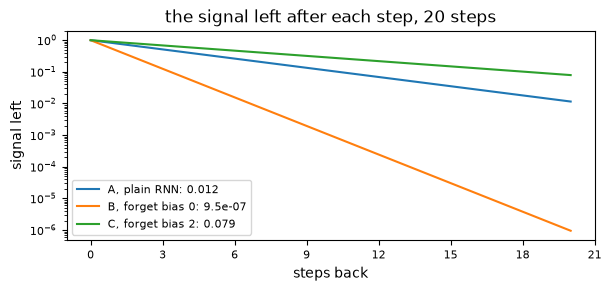

In [4]:
FACTORS = {"A, plain RNN": 0.8, "B, forget bias 0": sigma(0), "C, forget bias 2": sigma(2)}
STEPS = 20
signal(FACTORS, STEPS)

### Solution

In [5]:
a, b, c, open_gate = 0.8 ** 20, sigma(0) ** 20, sigma(2) ** 20, 0.95 ** 20
display(Markdown(f"After 20 steps C keeps {c:.3f}, A {a:.3f} and B {b:.1e}, so the ranking is C, A, B: a forget bias of 0 halves "
                 f"the signal at every step. A forget gate of 0.95 keeps {open_gate:.3f} after 20 steps and {0.95 ** 50:.3f} after 50, "
                 f"where the plain network keeps {0.8 ** 50:.1e}."))

After 20 steps C keeps 0.079, A 0.012 and B 9.5e-07, so the ranking is C, A, B: a forget bias of 0 halves the signal at every step. A forget gate of 0.95 keeps 0.358 after 20 steps and 0.077 after 50, where the plain network keeps 1.4e-05.

## 3. One cell-state step

The LSTM keeps a cell state and updates it by addition: it keeps the share
`F` of the old value `C_OLD` and writes the share `I` of the candidate
`CAND`. The output gate `O` sets how much of the new value the hidden state
shows. Run the cell. Then set `F` to 1 and `I` to 0, so the cell keeps its
old value, and compare `O` at 0.02 and at 0.95.

kept 0.9 × 2 = 1.800; written 0.5 × -0.8 = -0.400; new value 1.400
the hidden state shows 0.02 × tanh(1.400) = 0.018


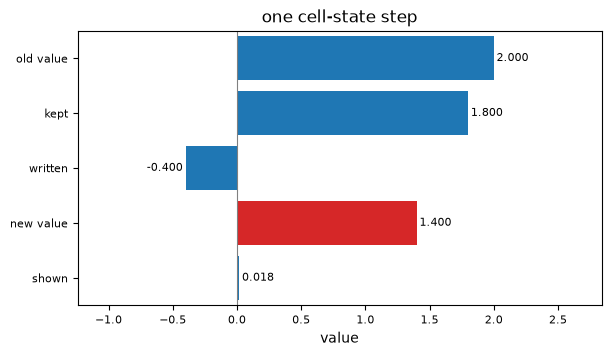

In [6]:
C_OLD, CAND = 2.0, -0.8
F, I, O = 0.9, 0.5, 0.02
cell_step(C_OLD, F, I, CAND, O)

### Solution

In [7]:
step = cell(2.0, 0.9, 0.5, -0.8, 0.02)
shut, opened = cell(2.0, 1, 0, -0.8, 0.02)[3], cell(2.0, 1, 0, -0.8, 0.95)[3]
display(Markdown(f"The entry keeps {step[0]:.1f}, adds {step[1]:.1f} and ends at {step[2]:.1f}. Kept at 2.0, it shows {shut:.3f} "
                 f"through an output gate of 0.02 and {opened:.3f} through one of 0.95: the cell holds the value, and the "
                 "output gate sets when the rest of the network sees it."))

The entry keeps 1.8, adds -0.4 and ends at 1.4. Kept at 2.0, it shows 0.019 through an output gate of 0.02 and 0.916 through one of 0.95: the cell holds the value, and the output gate sets when the rest of the network sees it.

## Appendix. One GRU step

The formulas behind the three steps:

state after a step: h = tanh(W_HH × old state + W_XH × word)

signal left after k steps at a factor f: f to the power k

new cell value: c = F × old value + I × candidate; shown: O × tanh(c)

A GRU merges the forget and input gates into one update gate z and has no
cell state: new value = (1 − z) × old value + z × candidate. The chart shows
one step at z 0.8 for an entry holding 1.0 and a candidate of -0.5.

kept 0.20 × 1 = 0.200; written 0.8 × -0.5 = -0.400; new value -0.200


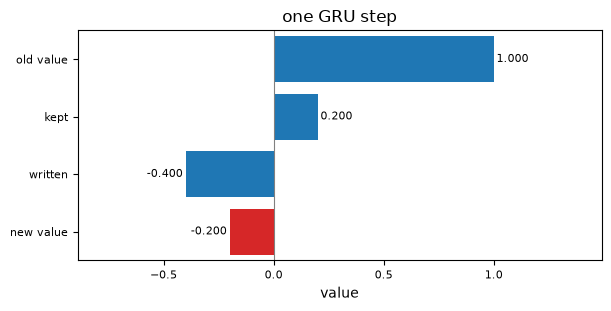

In [8]:
gru_step(1.0, 0.8, -0.5)

**Exercise.** Set `Z` to 0.05 and rerun the cell. What share of the old
value does the entry keep, and which forget gate keeps the same share at
every step?

kept 0.20 × 1 = 0.200; written 0.8 × -0.5 = -0.400; new value -0.200


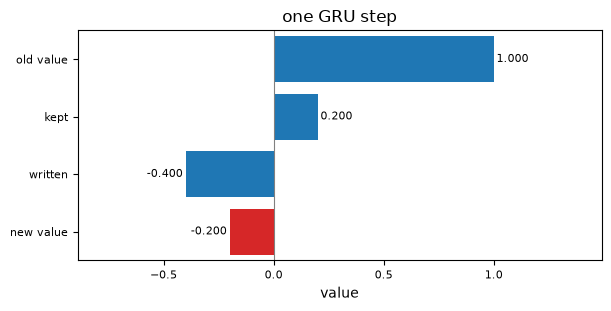

In [9]:
H_OLD, Z, CAND = 1.0, 0.8, -0.5
gru_step(H_OLD, Z, CAND)

### Solution

In [10]:
z = 0.05
display(Markdown(f"At z {z:g} the entry keeps {1 - z:.2f} of its old value at every step, as a forget gate of {1 - z:.2f} does, "
                 f"and over 20 steps that direct path keeps {(1 - z) ** 20:.3f} of the learning signal. At z 0.8 it keeps "
                 f"{1 - 0.8:.1f} and ends at {(1 - 0.8) * 1.0 + 0.8 * -0.5:.1f}."))

At z 0.05 the entry keeps 0.95 of its old value at every step, as a forget gate of 0.95 does, and over 20 steps that direct path keeps 0.358 of the learning signal. At z 0.8 it keeps 0.2 and ends at -0.2.